**Drive Connect**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Extract ZIP File**

In [ ]:
import zipfile

zip_path = '/content/drive/MyDrive/CV Project/mnist_png.zip'
extract_path = '/content/mnist_data/'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset ready!")

Dataset ready!


**Libraries Install+Import**

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


**Load Dataset**

In [ ]:
def load_mnist_png(base_path):
    images = []
    labels = []

    for digit in range(10):  # 0 to 9
        folder = os.path.join(base_path, str(digit))
        if not os.path.exists(folder):
            continue
        for img_file in os.listdir(folder):
            img_path = os.path.join(folder, img_file)
            img = Image.open(img_path).convert('L')  # grayscale
            img = np.array(img)
            images.append(img)
            labels.append(digit)

    return np.array(images), np.array(labels)

# Load karo
X_train, y_train = load_mnist_png('/content/mnist_data/mnist_png/training')
X_test,  y_test  = load_mnist_png('/content/mnist_data/mnist_png/testing')

print("Training images:", X_train.shape)
print("Testing images:", X_test.shape)

Training images: (60000, 28, 28)
Testing images: (10000, 28, 28)


**Check after loading the dataset**

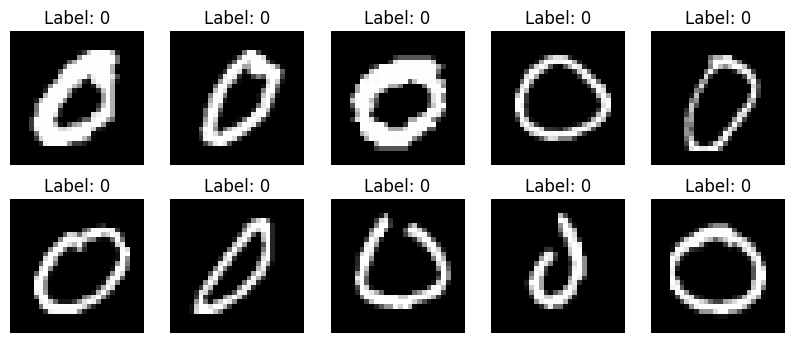

In [ ]:
plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[i*500], cmap='gray')
    plt.title(f"Label: {y_train[i*500]}")
    plt.axis('off')
plt.show()

**Preprocessing (Normalize + Reshape)**

In [ ]:
# Reshape for CNN (add channel dimension)
X_train = X_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
X_test  = X_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train sample:", y_train[:5])

X_train shape: (60000, 28, 28, 1)
X_test shape: (10000, 28, 28, 1)
y_train sample: [0 0 0 0 0]


**Dataset Summary**

In [ ]:
print("Total Training Images:", len(X_train))
print("Total Testing Images:", len(X_test))
print("Pixel value range: ", X_train.min(), "to", X_train.max())

# Har digit kitni baar hai
import numpy as np
unique, counts = np.unique(y_train, return_counts=True)
for digit, count in zip(unique, counts):
    print(f"Digit {digit}: {count} images")

Total Training Images: 60000
Total Testing Images: 10000
Pixel value range:  0.0 to 1.0
Digit 0: 5923 images
Digit 1: 6742 images
Digit 2: 5958 images
Digit 3: 6131 images
Digit 4: 5842 images
Digit 5: 5421 images
Digit 6: 5918 images
Digit 7: 6265 images
Digit 8: 5851 images
Digit 9: 5949 images


**Start CNN Model Training**

In [ ]:
from tensorflow import keras

model = keras.Sequential([
    keras.layers.Conv2D(32, (3,3), activation='relu',
                        input_shape=(28,28,1),
                        kernel_regularizer=keras.regularizers.l2(0.001)),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D(2,2),
    keras.layers.Dropout(0.25),

    keras.layers.Conv2D(64, (3,3), activation='relu',
                        kernel_regularizer=keras.regularizers.l2(0.001)),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D(2,2),
    keras.layers.Dropout(0.25),

    keras.layers.Conv2D(128, (3,3), activation='relu'),
    keras.layers.BatchNormalization(),

    keras.layers.Flatten(),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 3, 3, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 391,306 (1.49 MB)

 Trainable params: 390,858 (1.49 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=128),
    epochs=15,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 115s 238ms/step - accuracy: 0.8766 - loss: 0.4405 - val_accuracy: 0.9475 - val_loss: 0.2453
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 112s 239ms/step - accuracy: 0.9598 - loss: 0.1718 - val_accuracy: 0.9887 - val_loss: 0.0697
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 111s 236ms/step - accuracy: 0.9692 - loss: 0.1369 - val_accuracy: 0.9916 - val_loss: 0.0557
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 110s 235ms/step - accuracy: 0.9725 - loss: 0.1225 - val_accuracy: 0.9914 - val_loss: 0.0539
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 113s 241ms/step - accuracy: 0.9756 - loss: 0.1084 - val_accuracy: 0.9906 - val_loss: 0.0520
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 112s 239ms/step - accuracy: 0.9777 - loss: 0.1003 - val_accuracy: 0.9923 - val_loss: 0.0474
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 118s 252ms/step - accuracy: 0.9784 - loss: 0.0954 - val_accuracy: 0.9922 - val_loss: 0.0462
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 109s 232ms/step - accuracy: 0.9798 -

**Model Evaluate**

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

Test Accuracy: 98.93%
Test Loss: 0.0513


**Save Model on Drive-**

In [ ]:
# model.save('/content/drive/MyDrive/CV Project/mnist_model.h5')
# print("Model saved successfully!")
model.save('/content/drive/MyDrive/CV Project/mnist_model.keras')
print("New format saved!")
print("Model saved successfully!")

New format saved!
Model saved successfully!


**Accuracy + Loss Graph**

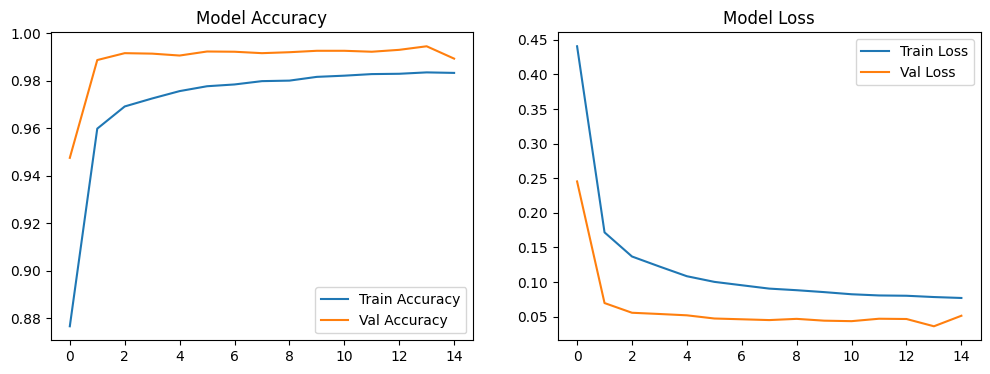

In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))

ax1.plot(history.history['accuracy'], label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('Model Accuracy')
ax1.legend()

ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('Model Loss')
ax2.legend()

plt.savefig('/content/drive/MyDrive/CV Project/training_graphs.png')
plt.show()

**Confusion Matrix**

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step


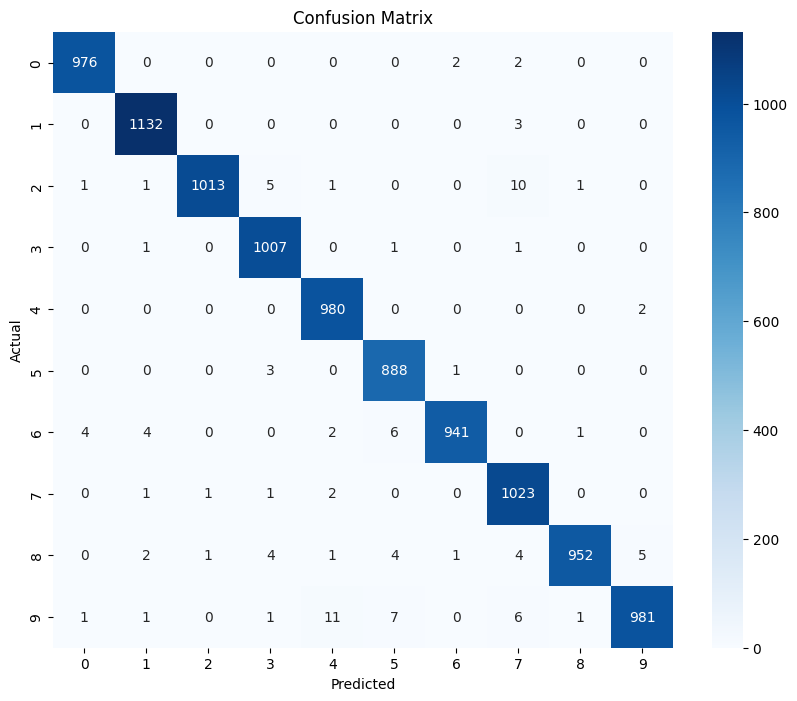

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      0.99      1135
           2       1.00      0.98      0.99      1032
           3       0.99      1.00      0.99      1010
           4       0.98      1.00      0.99       982
           5       0.98      1.00      0.99       892
           6       1.00      0.98      0.99       958
           7       0.98      1.00      0.99      1028
           8       1.00      0.98      0.99       974
           9       0.99      0.97      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred = model.predict(X_test)
y_pred_classes = y_pred.argmax(axis=1)

cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('/content/drive/MyDrive/CV Project/confusion_matrix.png')
plt.show()

print(classification_report(y_test, y_pred_classes))